# 1. Starting

In [45]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.13.0+cpu
False


## 1. UNDERSTANDING ABOUT THE DATASET

In [ ]:
from pathlib import Path
dataset_path = Path("data")

train_path = dataset_path/"train"
val_path = dataset_path/"val"
test_path = dataset_path/"test"

In [47]:
import os           #  The os module allows Python programs to interact with the operating system, such as working with files, directories, and environment variables.
os.listdir('data')

['test', 'train', 'val']

In [48]:
def count_images(folder):             # COUNT THE IMAGES
    counts ={}
    for cls in os.listdir(folder):
        class_path = folder/cls
        counts[cls]  = len(list(class_path.glob("*")))
    return counts    

In [49]:
train_counts = count_images(train_path)
val_counts = count_images(val_path)
test_counts = count_images(test_path)

print(train_counts)
print(val_counts)
print(test_counts)

{'normal': 7263, 'pneumonia': 4674, 'tuberculosis': 8513}
{'normal': 900, 'pneumonia': 570, 'tuberculosis': 862}
{'normal': 925, 'pneumonia': 580, 'tuberculosis': 1064}


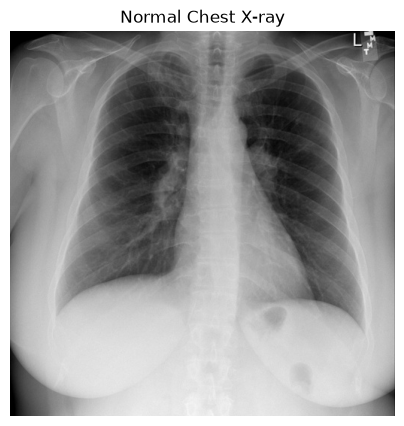

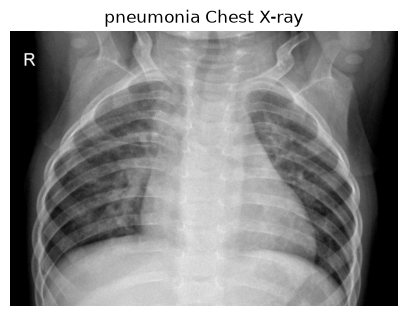

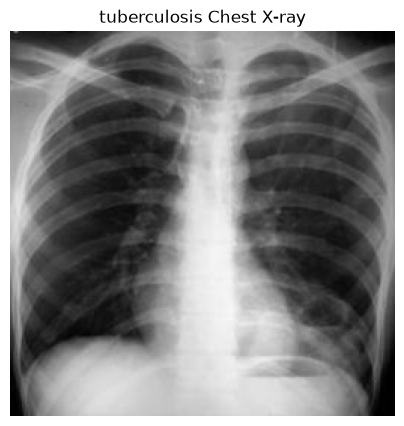

In [50]:
import matplotlib.pyplot as plt
from PIL import Image

normal_folder = train_path/"normal"
image_name = os.listdir(normal_folder)[5]
image_path = normal_folder/image_name
image = Image.open(image_path)
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("Normal Chest X-ray")
plt.axis("off")
plt.show()


pneumonia_folder = train_path/"pneumonia"
image_name = os.listdir(pneumonia_folder)[5]
image_path = pneumonia_folder/image_name
image = Image.open(image_path)
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("pneumonia Chest X-ray")
plt.axis("off")
plt.show()


tuberculosis_folder = train_path/"tuberculosis"
image_name = os.listdir(tuberculosis_folder)[5]
image_path = tuberculosis_folder/image_name
image = Image.open(image_path)
plt.figure(figsize=(5,5))
plt.imshow(image)
plt.title("tuberculosis Chest X-ray")
plt.axis("off")
plt.show()

## 2. EDA

In [53]:
normal_count = len(os.listdir(dataset_path/"train/normal"))
pneumonia_count = len(os.listdir(dataset_path/"train/pneumonia"))
tuberculosis_count = len(os.listdir(dataset_path/"train/tuberculosis"))

print("Normal Images :", normal_count)
print("Pneumonia Images :", pneumonia_count)
print("Tuberculosis Images :", tuberculosis_count)

Normal Images : 7263
Pneumonia Images : 4674
Tuberculosis Images : 8513


In [56]:
image_name = os.listdir(normal_folder)[0]
image_path = normal_folder/image_name
image = Image.open(image_path)

print(image.size)

(256, 256)


In [57]:
image_name = os.listdir(pneumonia_folder)[0]
image_path =pneumonia_folder/image_name
image = Image.open(image_path)

print(image.size)

(864, 520)


In [58]:
image_name = os.listdir(tuberculosis_folder)[0]
image_path =tuberculosis_folder/image_name
image = Image.open(image_path)

print(image.size)

(512, 512)


## 3. TRANSFORM

In [59]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5])

])

In [61]:
normal_folder = dataset_path/"train/normal"
image_name = os.listdir(normal_folder)[0]
image_path = normal_folder/image_name
image = Image.open(image_path)
image = transform(image)

print(image.shape)
print(image.max())
print(image.min())


torch.Size([3, 224, 224])
tensor(0.9373)
tensor(-0.9059)


In [64]:
from torchvision import datasets
from torch.utils.data import DataLoader


train_dataset = datasets.ImageFolder(       # this will add the labels
    root = dataset_path/"train",
    transform = transform
)

train_loader = DataLoader(                # dataloader
    train_dataset,
    batch_size = 32,
    shuffle = True
)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [65]:
print(train_dataset.classes)
print(train_dataset.class_to_idx)
print(len(train_dataset))

['normal', 'pneumonia', 'tuberculosis']
{'normal': 0, 'pneumonia': 1, 'tuberculosis': 2}
20450


# 1.MODEL

In [66]:
import torch
import torch.nn as nn

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1
        )
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(
            64 * 28 * 28,
            128
        )

        self.relu4 = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(
            128,
            3
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.flatten(x)

        x = self.fc1(x)
        x = self.relu4(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

In [67]:
model = CNN()
print(model)

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)


In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
print(device)
model = model.to(device)
best_accuracy = 0

cpu


In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(                 #  Without an optimizerthe CNN never learns.
    model.parameters(),
    lr=0.001  )

In [70]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()                 # is like cleaning the whiteboard before solving the next question.
        loss.backward()                       # "Which weights caused this error?"
        optimizer.step()                      # The optimizer uses the gradients from loss.backward() and updates the weights
        running_loss = running_loss + loss.item()
        average_loss = running_loss / len(train_loader)

    print("Epoch:", epoch + 1)
    print(f"Average Training Loss : {average_loss:.4f}")

Epoch: 1
Average Training Loss : 0.5631
Epoch: 2
Average Training Loss : 0.4770
Epoch: 3
Average Training Loss : 0.4527
Epoch: 4
Average Training Loss : 0.4400
Epoch: 5
Average Training Loss : 0.4287
Epoch: 6
Average Training Loss : 0.4231
Epoch: 7
Average Training Loss : 0.4182
Epoch: 8
Average Training Loss : 0.4188
Epoch: 9
Average Training Loss : 0.4131
Epoch: 10
Average Training Loss : 0.4067
Epoch: 11
Average Training Loss : 0.4039
Epoch: 12
Average Training Loss : 0.4023
Epoch: 13
Average Training Loss : 0.4002
Epoch: 14
Average Training Loss : 0.3982
Epoch: 15
Average Training Loss : 0.3966
Epoch: 16
Average Training Loss : 0.3960
Epoch: 17
Average Training Loss : 0.3926
Epoch: 18
Average Training Loss : 0.3956
Epoch: 19
Average Training Loss : 0.3929
Epoch: 20
Average Training Loss : 0.3946


### Validation Data


In [71]:
val_dataset = datasets.ImageFolder(
    root=dataset_path/"val",
    transform=transform
)

In [72]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [73]:
model.eval()                   # Stop training. Only test the model . This disables things like Dropout during evaluation.
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

validation_accuracy = (correct / total) * 100
print("Validation Accuracy:", validation_accuracy)
cnn_validation_accuracy = validation_accuracy

Validation Accuracy: 74.91423670668954


In [74]:
if validation_accuracy > best_accuracy:
    best_accuracy = validation_accuracy
    torch.save(model.state_dict(), "best_model.pth")

    print("Best model saved.")

Best model saved.


### Test data

In [75]:
test_dataset = datasets.ImageFolder(

    root = dataset_path/"test",
    transform = transform
)

In [76]:
test_loader = DataLoader(

    test_dataset,
    batch_size =32,
    shuffle = False
)

In [77]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (relu4): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

In [78]:
correct = 0
total = 0
with torch.no_grad():                  # This tells PyTorch:Don't calculate gradients.
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = (correct / total) * 100
print("Test Accuracy :", test_accuracy)
cnn_test_accuracy = test_accuracy

Test Accuracy : 74.62047489295446


In [ ]:
# Validation → During training
# Testing → After training is completely finished

# The test set is the final exam for your model.

## 3. Confusion Matrix


In [79]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [80]:
true_labels = []
predicted_labels = []
model.eval()
with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

In [81]:
accuracy = accuracy_score(
    true_labels,
    predicted_labels
)
print("Accuracy :", accuracy)


precision = precision_score(
    true_labels,
    predicted_labels,
    average="weighted"
)
print("Precision :", precision)

Accuracy : 0.7462047489295446
Precision : 0.7717071214904289


In [82]:
recall = recall_score(
    true_labels,
    predicted_labels,
    average="weighted"
)
print("Recall :", recall)


f1 = f1_score(
    true_labels,
    predicted_labels,
    average="weighted"
)
print("F1 Score :", f1)

Recall : 0.7462047489295446
F1 Score : 0.7443690124158534


In [83]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)
print(cm)

[[686 164  75]
 [ 12 567   1]
 [400   0 664]]


In [84]:
print(

    classification_report(
        true_labels,
        predicted_labels,
        target_names=test_dataset.classes
    ))

              precision    recall  f1-score   support

      normal       0.62      0.74      0.68       925
   pneumonia       0.78      0.98      0.86       580
tuberculosis       0.90      0.62      0.74      1064

    accuracy                           0.75      2569
   macro avg       0.77      0.78      0.76      2569
weighted avg       0.77      0.75      0.74      2569



In [85]:
torch.save(model.state_dict(), "cnn_chest_xray.pth")

print("CNN Model Saved Successfully!")

CNN Model Saved Successfully!


# 2. Using transfer Learning

In [86]:
import torch
import torch.nn as nn
import torchvision.models as models

model_2 = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)
print(model_2.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [88]:
for parameter in model_2.parameters():
    parameter.requires_grad = False     # ti=his code reduse the time significantly


model_2.fc = nn.Linear(
    in_features = 512,
    out_features = 3)
print(model_2.fc)

Linear(in_features=512, out_features=3, bias=True)


In [89]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model_2 = model_2.to(device)

In [90]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model_2.parameters(),
    lr=0.001
)

In [91]:
epochs = 20

for epoch in range(epochs):
    model_2.train()
    running_loss = 0
    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)
        outputs = model_2(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print("Epoch:", epoch + 1)
    print("Average Loss:", average_loss)

Epoch: 1
Average Loss: 0.5854464205447585
Epoch: 2
Average Loss: 0.5318411287851632
Epoch: 3
Average Loss: 0.5272256911033765
Epoch: 4
Average Loss: 0.5215489363530651
Epoch: 5
Average Loss: 0.5174701234325767
Epoch: 6
Average Loss: 0.5143000052310527
Epoch: 7
Average Loss: 0.5126806249376387
Epoch: 8
Average Loss: 0.5240568163339049
Epoch: 9
Average Loss: 0.5150599622633308
Epoch: 10
Average Loss: 0.5110918089514598
Epoch: 11
Average Loss: 0.519463222892955
Epoch: 12
Average Loss: 0.5073671055957675
Epoch: 13
Average Loss: 0.5056100559886545
Epoch: 14
Average Loss: 0.5061361204832793
Epoch: 15
Average Loss: 0.5085080402670428
Epoch: 16
Average Loss: 0.5077468356583268
Epoch: 17
Average Loss: 0.5055708243977278
Epoch: 18
Average Loss: 0.510363958007656
Epoch: 19
Average Loss: 0.4961976785212755
Epoch: 20
Average Loss: 0.5097299831453711


In [92]:
model_2.eval()      # Put the model in evaluation mode

correct = 0
total = 0
with torch.no_grad():     # Don't calculate gradients
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_2(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

validation_accuracy_2 = (correct / total) * 100

print("Validation Accuracy:", validation_accuracy_2)
resnet_validation_accuracy = validation_accuracy_2

Validation Accuracy: 74.91423670668954


In [93]:
model_2.eval()      # Evaluation mode
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_2(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy_2= (correct / total) * 100

print("Test Accuracy:", test_accuracy_2)
resnet_test_accuracy = test_accuracy_2

Test Accuracy: 73.91981315687038


In [94]:
import pandas as pd
comparison = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "ResNet18 (Transfer Learning)"
    ],

    "Validation Accuracy (%)": [
        cnn_validation_accuracy,
        resnet_validation_accuracy
    ],

    "Test Accuracy (%)": [
        cnn_test_accuracy,
        resnet_test_accuracy
    ]
})
comparison.round(2)

,Model,Validation Accuracy (%),Test Accuracy (%)
0,Custom CNN,74.91,74.62
1,ResNet18 (Transfer Learning),74.91,73.92


In [95]:
torch.save(model_2.state_dict(), "resnet18_chest_xray.pth")
print("Model Saved Successfully!")

Model Saved Successfully!


# PREDICT

In [96]:
class_names = [
    "Normal",
    "Pneumonia",
    "Tuberculosis"
]

In [ ]:
from PIL import Image
import torch

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    model_2.eval()

    with torch.no_grad():
        outputs = model_2(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, 1)
    predicted_class = class_names[prediction.item()]
    confidence = confidence.item() * 100

    return predicted_class, confidence

In [100]:
image_path = dataset_path/"test/normal/"/os.listdir(dataset_path/"test/normal")[0]
prediction, confidence = predict_image(image_path)

print("Prediction :", prediction)
print("Confidence :", confidence)

Prediction : Tuberculosis
Confidence : 56.666505336761475


In [101]:
%pip install -q gradio

Note: you may need to restart the kernel to use updated packages.


In [102]:
import gradio as gr

c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def gradio_predict(image):

    image = image.convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0)
    image = image.to(device)
    model_2.eval()
    with torch.no_grad():
        outputs = model_2(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, prediction = torch.max(probabilities, 1)
    predicted_class = class_names[prediction.item()]
    confidence = confidence.item() * 100
    return f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"

In [ ]:
app = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Text(),
    title="AI Powered Chest X-ray Disease Detection",
    description="Upload a Chest X-ray image to detect Normal, Pneumonia, or Tuberculosis."
)

In [ ]:
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\gradio\routes.py", line 674, in main
  File "c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\starlette\templating.py", line 148, in TemplateResponse
  File "c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\starlette\templating.py", line 115, in get_template
  File "c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\jinja2\environment.py", line 1016, in get_template
  File "c:\Users\YASH RAJ\OneDrive\Desktop\PROJECTS\ML_01(basic)\AI-powered Pneumonia Detection from Chest X-ray\venv\Lib\site-packages\jinja2\environment.py", line 975, in _load_templa